# **Simulação de Carteiras**

### **Introdução**

Iremos fazer uma simulação de carteira em comparação ao índice BOVESPA "IBOV"

### **Para fins de simplificação**

- Apenas um aporte em cada ação
- Os aportes foram todos no mesmo dia

### **1. Importação das Bibliotecas**

In [96]:
import pandas as pd
import numpy as np
import matplotlib as pl
import yfinance as yf


### 2. **Configurar a carteira de investimentos**

In [48]:
carteira = {'PETR4.SA': 2000, 'ITUB3.SA': 2300,
            'ABEV3.SA': 5200, 'EGIE3.SA': 4800,
            'SMAL11.SA':1300, 'VALE3.SA': 1400,
            'COCA34.SA':1000, 'AAPL34.SA': 2000}           

In [49]:
# Transformando as chaves em uma lista

list(carteira.keys())

['PETR4.SA',
 'ITUB3.SA',
 'ABEV3.SA',
 'EGIE3.SA',
 'SMAL11.SA',
 'VALE3.SA',
 'COCA34.SA',
 'AAPL34.SA']

In [50]:
# Somatório da minha carteira no valor de R$ 20.000

sum(carteira.values())

20000

### **3. Importando os dados**

In [51]:
inicio = '2016-01-01'
fim = '2026-01-01'

In [52]:
yf.download(list(carteira.keys()), start=inicio, end=fim)

[*********************100%***********************]  8 of 8 completed


Price           Close                                                         \
Ticker      AAPL34.SA   ABEV3.SA  COCA34.SA   EGIE3.SA   ITUB3.SA   PETR4.SA   
Date                                                                           
2016-01-04   4.749913  11.421398  20.954035   9.478621   6.204128   1.805672   
2016-01-05   4.749913  11.600587  20.954035   9.591808   6.335733   1.755733   
2016-01-06   4.643806  11.487764  20.954035   9.449599   6.298130   1.682139   
2016-01-07   4.430466  11.182487  20.813761   9.229032   6.222929   1.645343   
2016-01-08   4.479004  11.328487  20.813761   9.098434   6.319614   1.647971   
...               ...        ...        ...        ...        ...        ...   
2025-12-22  75.419334  13.120000  64.659760  29.888947  34.994606  29.741398   
2025-12-23  74.999901  13.470000  63.795647  30.687695  35.398060  29.901339   
2025-12-26  76.238243  13.720000  64.798813  30.845472  35.668468  29.999990   
2025-12-29  75.798836  13.870000  64.451180  30.490473  35.618988  30.315676   
2025-12-30  74.800171  13.860000  64.043961  30.934221  35.965286  30.404463   

Price                                   High             ...        Open  \
Ticker       SMAL11.SA   VALE3.SA  AAPL34.SA   ABEV3.SA  ...   SMAL11.SA   
Date                                                     ...               
2016-01-04   39.939999   6.274101   4.763458  11.766496  ...   40.849998   
2016-01-05   39.610001   6.190052   4.749913  11.627133  ...   40.400002   
2016-01-06   39.279999   5.735192   4.643806  11.600585  ...   39.090000   
2016-01-07   38.599998   5.394047   4.548988  11.494401  ...   40.000000   
2016-01-08   38.759998   5.211114   4.516253  11.414762  ...   38.900002   
...                ...        ...        ...        ...  ...         ...   
2025-12-22  109.309998  72.919998  75.948634  13.300000  ...  110.610001   
2025-12-23  111.610001  72.900002  75.659025  13.570000  ...  109.300003   
2025-12-26  112.199997  73.120003  76.238243  13.820000  ...  110.500000   
2025-12-29  111.400002  72.120003  76.378065  13.870000  ...  112.529999   
2025-12-30  112.449997  71.959999  75.419340  14.090000  ...  112.320000   

Price                    Volume                                        \
Ticker       VALE3.SA AAPL34.SA  ABEV3.SA COCA34.SA EGIE3.SA ITUB3.SA   
Date                                                                    
2016-01-04   6.175219    100000  13206900         0  1227100   315563   
2016-01-05   6.264213      1600  10774200         0  1113175   113101   
2016-01-06   5.972510      2400   7739100         0  2839200   206200   
2016-01-07   5.567092    520000  15316400     24600  1981700   251441   
2016-01-08   5.473153    144800  10684000         0  1620850   138339   
...               ...       ...       ...       ...      ...      ...   
2025-12-22  71.029999    260916  26993300     24521  2669700  1940108   
2025-12-23  73.230003     87451  45087200     37490   942800   889817   
2025-12-26  72.860001    104140  29118400     21778   579200   554500   
2025-12-29  73.190002     84282  20303700     26306  1201800   627500   
2025-12-30  72.500000     52038  25304800     23315  1511300   618800   

Price                                      
Ticker      PETR4.SA  SMAL11.SA  VALE3.SA  
Date                                       
2016-01-04  45962100     7460.0   4587900  
2016-01-05  29446700    20380.0   2693500  
2016-01-06  67507200     3420.0   6758900  
2016-01-07  57387900      610.0   6450400  
2016-01-08  52100300      240.0   4429400  
...              ...        ...       ...  
2025-12-22  35896900  1528345.0  27853000  
2025-12-23  35703900  2551074.0  17140900  
2025-12-26  20178600  2406555.0  16368800  
2025-12-29  20588100   772348.0  19963700  
2025-12-30  16880600  1328965.0  17085400  

[2491 rows x 40 columns]

In [53]:
# Para fins de análise de carteira precisamos somente do fechamento diário
# Porém, o yfinance trás o fechamento ajustado por dividendos
# Vamos retirar a barra de progresso

precos = yf.download(list(carteira.keys()), start=inicio, end=fim, progress=False)['Close']
precos

Ticker,AAPL34.SA,ABEV3.SA,COCA34.SA,EGIE3.SA,ITUB3.SA,PETR4.SA,SMAL11.SA,VALE3.SA
Date,,,,,,,,
2016-01-04,4.749913,11.421398,20.954035,9.478621,6.204128,1.805672,39.939999,6.274101
2016-01-05,4.749913,11.600587,20.954035,9.591808,6.335733,1.755733,39.610001,6.190052
2016-01-06,4.643806,11.487764,20.954035,9.449599,6.298130,1.682139,39.279999,5.735192
2016-01-07,4.430466,11.182487,20.813761,9.229032,6.222929,1.645343,38.599998,5.394047
2016-01-08,4.479004,11.328487,20.813761,9.098434,6.319614,1.647971,38.759998,5.211114
...,...,...,...,...,...,...,...,...
2025-12-22,75.419334,13.120000,64.659760,29.888947,34.994606,29.741398,109.309998,72.919998
2025-12-23,74.999901,13.470000,63.795647,30.687695,35.398060,29.901339,111.610001,72.900002
2025-12-26,76.238243,13.720000,64.798813,30.845472,35.668468,29.999990,112.199997,73.120003


### **4. Simulação da cateira fictícia**

In [54]:
# Precisamos saber os preços do primeiro dia do aporte, para a partir disso podemos acompanhar a 
# evolução da carteira

primeiro = precos.iloc[0]
primeiro


Ticker
AAPL34.SA     4.749913
ABEV3.SA     11.421398
COCA34.SA    20.954035
EGIE3.SA      9.478621
ITUB3.SA      6.204128
PETR4.SA      1.805672
SMAL11.SA    39.939999
VALE3.SA      6.274101
Name: 2016-01-04 00:00:00, dtype: float64

In [97]:
# Vamos transformar a nossa carteira em um DataFrame

compras_df = pd.Series(carteira, index = list(carteira.keys()))

compras_df



PETR4.SA     2000
ITUB3.SA     2300
ABEV3.SA     5200
EGIE3.SA     4800
SMAL11.SA    1300
VALE3.SA     1400
COCA34.SA    1000
AAPL34.SA    2000
dtype: int64

**Quantidade de papéis comprados em cada ativo**

In [56]:
# Precisamos calcular a quantidade de papéis que consiguimos comprar com o aporte de R$20000

qtd_de_acoes = round(compras_df / primeiro, 0) # precisamos arredondar em zero casas decimais, pois os papéis são valores inteiros

patrimonio = precos * qtd_de_acoes



# Agora temos um dataframe que diz o valor em reais de cada posição ao longo do tempo

In [58]:
# Precisamos ver o quanto o nosso patrimônio evoluiu ao longo do tempo
# Portando, iremos somar a variação do patrimônio ao longo do tempo

patrimonio['PATRIMÔNIO TOTAL'] = patrimonio.sum(axis= 1)


In [59]:
patrimonio

Ticker,AAPL34.SA,ABEV3.SA,COCA34.SA,EGIE3.SA,ITUB3.SA,PETR4.SA,SMAL11.SA,VALE3.SA,PATRIMÔNIO TOTAL
Date,,,,,,,,,
2016-01-04,1999.713263,5196.736164,1005.793671,4796.182470,2301.731586,2000.684367,1318.019955,1399.124580,20017.986056
2016-01-05,1999.713263,5278.267035,1005.793671,4853.455009,2350.557096,1945.352707,1307.130020,1380.381497,20120.650299
2016-01-06,1955.042519,5226.932783,1005.793671,4781.497229,2336.606243,1863.810452,1296.239960,1278.947776,19744.870632
2016-01-07,1865.226059,5088.031373,999.060516,4669.889971,2308.706836,1823.040116,1273.799950,1202.872539,19230.627360
2016-01-08,1885.660645,5154.461765,999.060516,4603.807831,2344.576946,1825.952302,1279.079945,1162.078406,19254.678356
...,...,...,...,...,...,...,...,...,...
2025-12-22,31751.539787,5969.599948,3103.668457,15123.806946,12982.998833,32953.468826,3607.229919,16261.159592,121753.472308
2025-12-23,31574.958244,6128.850121,3062.191040,15527.973442,13132.680202,33130.683144,3683.130020,16256.700340,122497.166554
2025-12-26,32096.300346,6242.600121,3110.343018,15607.809002,13233.001804,33239.989433,3702.599899,16305.760612,123538.404237


### **5. Comparação IBOV**

In [95]:
ibov = yf.download('^BVSP', start= inicio, end= fim, progress= False)['Close']



In [83]:
ibov = pd.DataFrame(ibov)


In [82]:
ibov.rename(columns= {'Close': 'IBOV'}, inplace= True)


**Juntando tudo em um DataFrame só**

In [81]:
consolidado = pd.merge(ibov, patrimonio, how= 'inner', on= 'Date')
consolidado

Ticker,^BVSP,AAPL34.SA,ABEV3.SA,COCA34.SA,EGIE3.SA,ITUB3.SA,PETR4.SA,SMAL11.SA,VALE3.SA,PATRIMÔNIO TOTAL
Date,,,,,,,,,,
2016-01-04,42141.0,1999.713263,5196.736164,1005.793671,4796.182470,2301.731586,2000.684367,1318.019955,1399.124580,20017.986056
2016-01-05,42419.0,1999.713263,5278.267035,1005.793671,4853.455009,2350.557096,1945.352707,1307.130020,1380.381497,20120.650299
2016-01-06,41773.0,1955.042519,5226.932783,1005.793671,4781.497229,2336.606243,1863.810452,1296.239960,1278.947776,19744.870632
2016-01-07,40695.0,1865.226059,5088.031373,999.060516,4669.889971,2308.706836,1823.040116,1273.799950,1202.872539,19230.627360
2016-01-08,40612.0,1885.660645,5154.461765,999.060516,4603.807831,2344.576946,1825.952302,1279.079945,1162.078406,19254.678356
...,...,...,...,...,...,...,...,...,...,...
2025-12-22,158142.0,31751.539787,5969.599948,3103.668457,15123.806946,12982.998833,32953.468826,3607.229919,16261.159592,121753.472308
2025-12-23,160456.0,31574.958244,6128.850121,3062.191040,15527.973442,13132.680202,33130.683144,3683.130020,16256.700340,122497.166554
2025-12-26,160897.0,32096.300346,6242.600121,3110.343018,15607.809002,13233.001804,33239.989433,3702.599899,16305.760612,123538.404237


Obs: 

As magnitudes estão muito destoantes, enquanto o Ibov possui 42.141 pontos a Apple possui apenas 1999, dessa maneira obteremmos
dados distorcidos devido a diferença de escala.

Então, para resolvermos este problema iremos fazer um processo chamado de (normalização), fazendo com que as nossas cotações comecem no valor de 1, dessa maneira, calcularemos a rentabilidade acumulada e não mais o preço.

**Normalização**

In [88]:
consolidado_ajustado = consolidado / consolidado.iloc[0]

consolidado_ajustado

Ticker,^BVSP,AAPL34.SA,ABEV3.SA,COCA34.SA,EGIE3.SA,ITUB3.SA,PETR4.SA,SMAL11.SA,VALE3.SA,PATRIMÔNIO TOTAL
Date,,,,,,,,,,
2016-01-04,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
2016-01-05,1.006597,1.000000,1.015689,1.000000,1.011941,1.021213,0.972344,0.991738,0.986604,1.005129
2016-01-06,0.991267,0.977661,1.005811,1.000000,0.996938,1.015151,0.931586,0.983475,0.914106,0.986356
2016-01-07,0.965687,0.932747,0.979082,0.993306,0.973668,1.003030,0.911208,0.966450,0.859732,0.960667
2016-01-08,0.963717,0.942966,0.991865,0.993306,0.959890,1.018614,0.912664,0.970456,0.830575,0.961869
...,...,...,...,...,...,...,...,...,...,...
2025-12-22,3.752687,15.878046,1.148721,3.085790,3.153301,5.640536,16.471098,2.736855,11.622381,6.082204
2025-12-23,3.807598,15.789743,1.179365,3.044552,3.237569,5.705565,16.559675,2.794442,11.619194,6.119355
2025-12-26,3.818063,16.050451,1.201254,3.092427,3.254215,5.749151,16.614310,2.809214,11.654259,6.171370


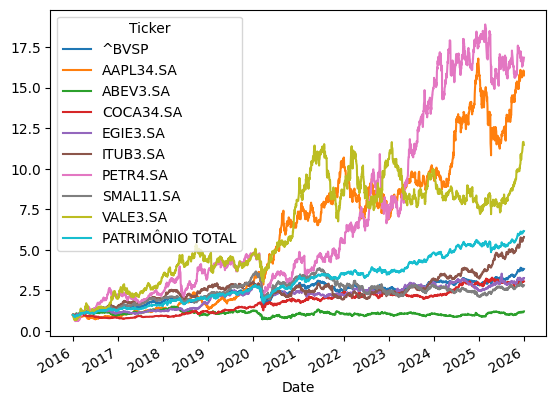

In [89]:
consolidado_ajustado.plot();

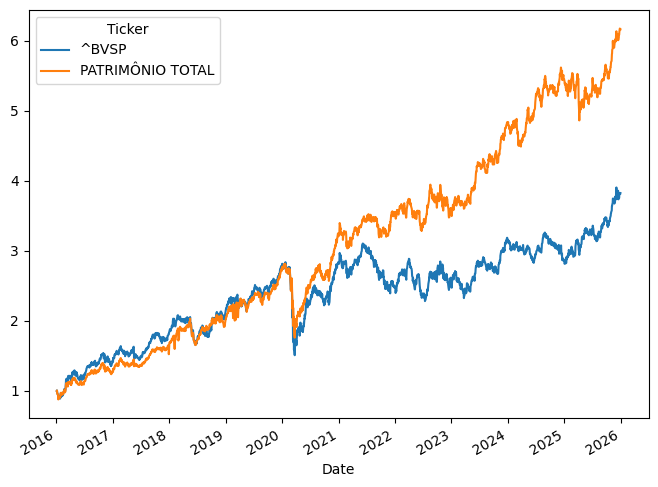

In [93]:
consolidado_ajustado[['^BVSP', 'PATRIMÔNIO TOTAL']].plot(figsize= (8, 6));

In [ ]:
def simulacao_carteira()